# BROUILLON D'ESSAIS — Modeling Experiments
## Return/Refund Propensity Classification (Olist)

Ce notebook sert uniquement a tester plusieurs configurations d'algorithmes
pour une prediction du risque **avant livraison**.
Les meilleures configurations sont ensuite reportees dans `02_Modeling.ipynb`.

---
### Plan d'essais
1. Chargement & preprocessing
2. Essais multi-configurations (LogReg, Decision Tree, Random Forest, XGBoost)
3. Tableau comparatif des essais
4. Selection des meilleures configurations

## 1. Imports & Chargement

In [1]:
# --- Librairies ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os
import joblib  # Pour sauvegarder le modèle final

# --- Machine Learning : Modèles ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# XGBoost (bonus — commenter si non installé)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️  XGBoost non installé — pip install xgboost')

# --- Machine Learning : Optimisation & Évaluation ---
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score
)

# --- Configuration ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42  # Graine aléatoire pour la reproductibilité

# Ajouter le dossier racine au PATH
sys.path.append(os.path.abspath('..'))

print('✅ Imports réussis')

✅ Imports réussis


In [2]:
# Charger le DataFrame maître pré-généré
df = pd.read_csv('../data/master.csv')
print(f"Dataset chargé depuis master.csv : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Dataset chargé depuis master.csv : 99,441 lignes × 22 colonnes


---
## 2. Preprocessing Complet

On utilise le pipeline de `src/preprocessing.py` qui enchaîne automatiquement toutes les étapes.

In [3]:
from src.preprocessing import full_preprocessing_pipeline

# Lance le pipeline complet : nettoyage → feature engineering → encodage → split → normalisation
X_train, X_test, y_train, y_test, scaler = full_preprocessing_pipeline(df)

print(f'\nX_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')

PIPELINE DE PREPROCESSING

📅 Conversion des dates...
  ✅ 5 colonnes converties en datetime

🔍 Filtrage des commandes valides...
  ✅ 1,729 commandes hors périmètre supprimées → 97,712 commandes restantes

🧹 Gestion des valeurs manquantes...
  ✅ product_weight_g: 783 NaN → médiane (700.00)
  ✅ product_photos_qty: 2140 NaN → médiane (2.00)
  ✅ total_price: 767 NaN → médiane (86.80)
  ✅ total_freight: 767 NaN → médiane (17.16)
  ✅ payment_value: 1 NaN → médiane (105.28)
  ✅ payment_installments: 1 NaN → médiane (2.00)
  ✅ item_count: 767 NaN → médiane (1.00)
  ✅ product_category_name_english: 2161 NaN → 'unknown'
  ✅ payment_type: 1 NaN → 'unknown'

⚙️  Feature Engineering...
  ✅ 4 nouvelles features créées : freight_ratio, price_per_item, purchase_month, purchase_day_of_week

  Distribution de la variable cible (is_return_refund_risk) :
    Risque élevé (1) :   1,234 (1.3%)
    Risque faible(0) :  96,478 (98.7%)

🔡 Encodage des variables catégorielles...
  ✅ payment_type encodé → payment_

In [4]:
# Vérification du déséquilibre dans le train set
print('Distribution des classes dans y_train :')
print(y_train.value_counts())
print(f'\nRatio : {y_train.value_counts()[1] / y_train.value_counts()[0]:.2f}:1')

# NOTE : on utilisera class_weight='balanced' dans les modèles pour compenser

Distribution des classes dans y_train :
is_return_refund_risk
0    77182
1      987
Name: count, dtype: int64

Ratio : 0.01:1


---
## 3. Modèle 1 — Régression Logistique (Baseline)

Baseline pour Return/Refund propensity avant essais multi-paramètres.

In [5]:
print('=' * 50)
print('MODELE 1 - REGRESSION LOGISTIQUE')
print('=' * 50)

lr = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs'
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'\n{classification_report(y_test, y_pred_lr, target_names=["Low Risk", "High Risk"])}')

MODELE 1 - REGRESSION LOGISTIQUE

Accuracy  : 0.6811
F1-Score  : 0.7986
AUC-ROC   : 0.7950

              precision    recall  f1-score   support

    Low Risk       1.00      0.68      0.81     19296
   High Risk       0.03      0.79      0.06       247

    accuracy                           0.68     19543
   macro avg       0.51      0.73      0.43     19543
weighted avg       0.98      0.68      0.80     19543



---
## 4. Modèle 2 — Arbre de Décision

Baseline non linéaire pour Return/Refund propensity.

In [6]:
print('=' * 50)
print('MODELE 2 - ARBRE DE DECISION')
print('=' * 50)

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    criterion='gini'
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_dt, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_dt):.4f}')
print(f'\n{classification_report(y_test, y_pred_dt, target_names=["Low Risk", "High Risk"])}')

MODELE 2 - ARBRE DE DECISION

Accuracy  : 0.8991
F1-Score  : 0.9363
AUC-ROC   : 0.8349

              precision    recall  f1-score   support

    Low Risk       1.00      0.90      0.95     19296
   High Risk       0.09      0.73      0.15       247

    accuracy                           0.90     19543
   macro avg       0.54      0.82      0.55     19543
weighted avg       0.98      0.90      0.94     19543



  ✅ 5 colonnes converties en datetime
  ✅ 1,729 commandes hors périmètre supprimées → 97,712 commandes restantes
  ✅ product_weight_g: 783 NaN → médiane (700.00)
  ✅ product_photos_qty: 2140 NaN → médiane (2.00)
  ✅ total_price: 767 NaN → médiane (86.80)
  ✅ total_freight: 767 NaN → médiane (17.16)
  ✅ payment_value: 1 NaN → médiane (105.28)
  ✅ payment_installments: 1 NaN → médiane (2.00)
  ✅ item_count: 767 NaN → médiane (1.00)
  ✅ product_category_name_english: 2161 NaN → 'unknown'
  ✅ payment_type: 1 NaN → 'unknown'
  ✅ 4 nouvelles features créées : freight_ratio, price_per_item, purchase_month, purchase_day_of_week

  Distribution de la variable cible (is_return_refund_risk) :
    Risque élevé (1) :   1,234 (1.3%)
    Risque faible(0) :  96,478 (98.7%)
  ✅ payment_type encodé → payment_type_encoded (6 modalités)
  ✅ customer_state encodé → customer_state_encoded (27 modalités)
  ✅ product_category_name_english encodé → product_category_name_english_encoded (72 modalités)

  ✅ 14 f

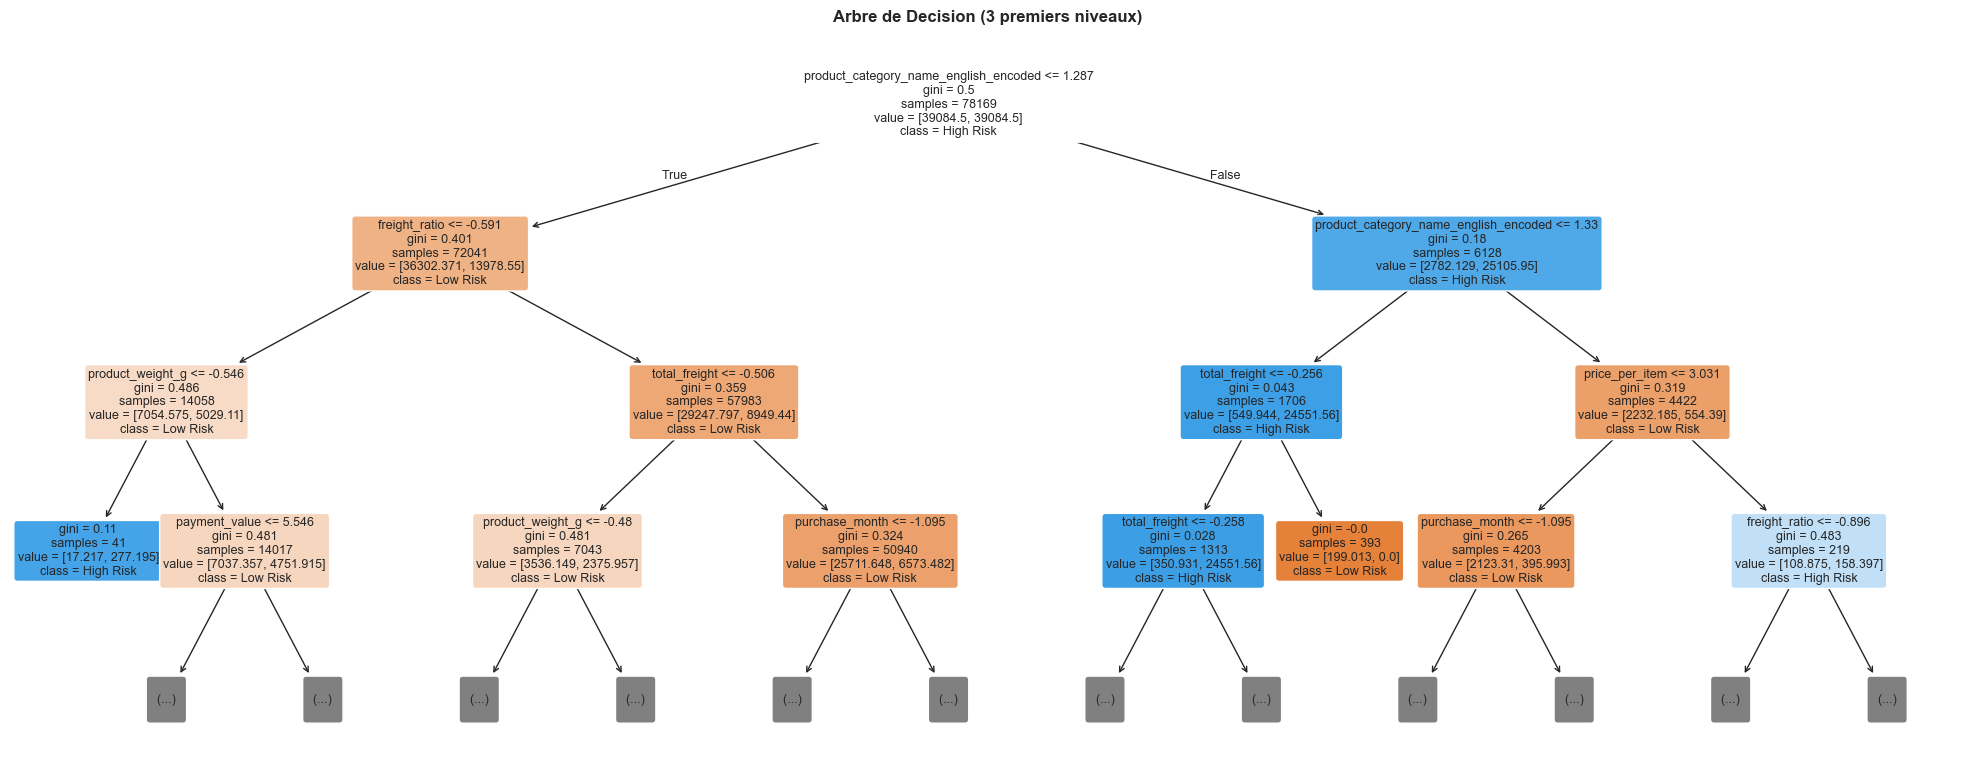

In [7]:
# Visualisation des 3 premiers niveaux de l'arbre
from src.preprocessing import (
    convert_dates, filter_valid_orders, handle_missing_values,
    create_features, create_return_refund_target, encode_categorical, select_features
)

df_temp = convert_dates(df.copy())
df_temp = filter_valid_orders(df_temp)
df_temp = handle_missing_values(df_temp)
df_temp = create_features(df_temp)
df_temp = create_return_refund_target(df_temp)
df_temp = encode_categorical(df_temp)
X_named, _ = select_features(df_temp)
feature_names = X_named.columns.tolist()

plt.figure(figsize=(20, 8))
plot_tree(
    dt, max_depth=3,
    feature_names=feature_names,
    class_names=['Low Risk', 'High Risk'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Arbre de Decision (3 premiers niveaux)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Modèle 3 — Random Forest

Baseline ensembliste pour Return/Refund propensity.

In [8]:
print('=' * 50)
print('MODELE 3 - RANDOM FOREST')
print('=' * 50)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=30,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=["Low Risk", "High Risk"])}')

MODELE 3 - RANDOM FOREST

Accuracy  : 0.9955
F1-Score  : 0.9951
AUC-ROC   : 0.8784

              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00     19296
   High Risk       0.99      0.66      0.79       247

    accuracy                           1.00     19543
   macro avg       0.99      0.83      0.89     19543
weighted avg       1.00      1.00      1.00     19543



---
## 6. Modèle 4 — XGBoost

Baseline boosting pour Return/Refund propensity.

In [9]:
if XGBOOST_AVAILABLE:
    print('=' * 50)
    print('MODELE 4 - XGBOOST')
    print('=' * 50)

    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos_weight = neg_count / max(pos_count, 1)

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
)

    xgb.fit(X_train, y_train)

    y_pred_xgb = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

    print(f'\nAccuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}')
    print(f'F1-Score  : {f1_score(y_test, y_pred_xgb, average="weighted"):.4f}')
    print(f'AUC-ROC   : {roc_auc_score(y_test, y_proba_xgb):.4f}')
    print(f'\n{classification_report(y_test, y_pred_xgb, target_names=["Low Risk", "High Risk"])}')
else:
    print('XGBoost non disponible. Installer avec : pip install xgboost')

MODELE 4 - XGBOOST

Accuracy  : 0.9876
F1-Score  : 0.9884
AUC-ROC   : 0.8919

              precision    recall  f1-score   support

    Low Risk       1.00      0.99      0.99     19296
   High Risk       0.51      0.67      0.58       247

    accuracy                           0.99     19543
   macro avg       0.75      0.83      0.79     19543
weighted avg       0.99      0.99      0.99     19543



---
## 7. Comparaison des Modèles


📊 Tableau Comparatif des Modèles :
         model_name  accuracy       f1      auc
      Random Forest  0.995548 0.995104 0.878443
            XGBoost  0.987566 0.988429 0.891853
      Decision Tree  0.899094 0.936336 0.834927
Logistic Regression  0.681113 0.798565 0.794982


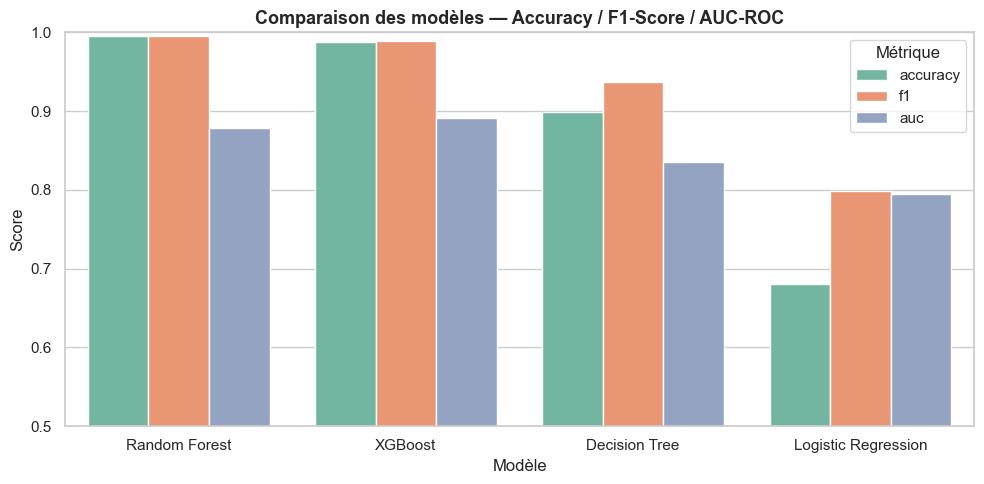

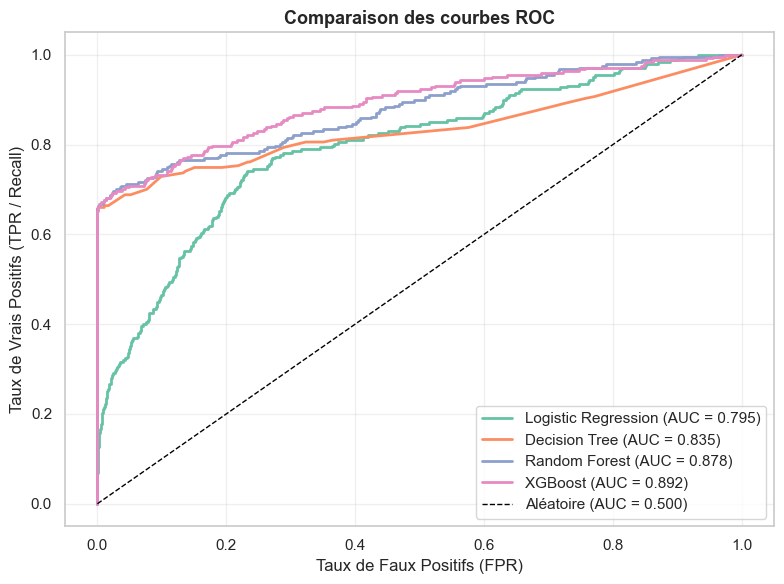

In [10]:
from src.evaluation import compare_models, plot_roc_curves

# Compilation des résultats de tous les modèles
results = [
    {'model_name': 'Logistic Regression',
     'accuracy': accuracy_score(y_test, y_pred_lr),
     'f1':       f1_score(y_test, y_pred_lr, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_lr)},

    {'model_name': 'Decision Tree',
     'accuracy': accuracy_score(y_test, y_pred_dt),
     'f1':       f1_score(y_test, y_pred_dt, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_dt)},

    {'model_name': 'Random Forest',
     'accuracy': accuracy_score(y_test, y_pred_rf),
     'f1':       f1_score(y_test, y_pred_rf, average='weighted'),
     'auc':      roc_auc_score(y_test, y_proba_rf)},
]

if XGBOOST_AVAILABLE:
    results.append({
        'model_name': 'XGBoost',
        'accuracy': accuracy_score(y_test, y_pred_xgb),
        'f1':       f1_score(y_test, y_pred_xgb, average='weighted'),
        'auc':      roc_auc_score(y_test, y_proba_xgb)
    })

df_results = compare_models(results)

# Courbes ROC comparatives
models_dict = {
    'Logistic Regression': lr,
    'Decision Tree':       dt,
    'Random Forest':       rf,
}
if XGBOOST_AVAILABLE:
    models_dict['XGBoost'] = xgb

plot_roc_curves(models_dict, X_test, y_test)

---
## 8. Essais multiples d'hyperparametres

On teste plusieurs configurations pour chaque algorithme.
Objectif: comparer les scores et retenir la meilleure version par algorithme.

In [11]:
from sklearn.base import clone

def score_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'auc': roc_auc_score(y_test, y_proba),
    }

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / max(pos_count, 1)

# Anciennes configurations du notebook principal (archivées, non scorées dans les trials)
former_modeling_configs = {
    'DecisionTree_main_old': DecisionTreeClassifier(max_depth=8, min_samples_split=50, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest_main_old': RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_split=30, min_samples_leaf=10, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
}
if XGBOOST_AVAILABLE:
    former_modeling_configs['XGBoost_main_old'] = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0
    )

trial_bank = {
    'LogReg': [
        # Trial 1 (retenu dans 02_Modeling)
        LogisticRegression(max_iter=500, class_weight='balanced', C=1.0, solver='lbfgs', random_state=RANDOM_STATE),
        LogisticRegression(max_iter=700, class_weight='balanced', C=0.5, solver='lbfgs', random_state=RANDOM_STATE),
        LogisticRegression(max_iter=800, class_weight='balanced', C=2.0, solver='lbfgs', random_state=RANDOM_STATE),
    ],
    'DecisionTree': [
        # Trial 1 (retenu dans 02_Modeling)
        DecisionTreeClassifier(max_depth=6, min_samples_split=50, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
        DecisionTreeClassifier(max_depth=8, min_samples_split=40, min_samples_leaf=15, class_weight='balanced', random_state=RANDOM_STATE),
        DecisionTreeClassifier(max_depth=12, min_samples_split=30, min_samples_leaf=10, class_weight='balanced', random_state=RANDOM_STATE),
    ],
    'RandomForest': [
        RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=40, min_samples_leaf=15, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        # Ancienne config du notebook principal (equivaut a l'ancien modele principal)
        RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_split=30, min_samples_leaf=10, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        # Trial 3 (retenu dans 02_Modeling)
        RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_split=20, min_samples_leaf=5, max_features='log2', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    ],
}

if XGBOOST_AVAILABLE:
    trial_bank['XGBoost'] = [
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
        # Ancienne config du notebook principal (equivaut a l'ancien modele principal)
        XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
        # Trial 3 (retenu dans 02_Modeling)
        XGBClassifier(n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.7, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    ]

trial_rows = []
best_by_algo = {}

for algo_name, configs in trial_bank.items():
    print(f'\n===== {algo_name} =====')
    best_f1 = -1
    best_model = None
    best_idx = None

    for i, model in enumerate(configs, start=1):
        metrics = score_model(model, X_train, y_train, X_test, y_test)
        row = {
            'algorithm': algo_name,
            'trial_id': i,
            'accuracy': metrics['accuracy'],
            'f1': metrics['f1'],
            'auc': metrics['auc'],
            'params': str(model.get_params()),
        }
        trial_rows.append(row)
        print(f"Trial {i}: F1={metrics['f1']:.4f} | AUC={metrics['auc']:.4f} | ACC={metrics['accuracy']:.4f}")

        if metrics['f1'] > best_f1:
            best_f1 = metrics['f1']
            best_model = clone(model)
            best_idx = i

    best_model.fit(X_train, y_train)
    best_by_algo[algo_name] = {'trial_id': best_idx, 'model': best_model, 'f1': best_f1}

df_trials = pd.DataFrame(trial_rows).sort_values(['algorithm', 'f1'], ascending=[True, False])
df_trials.head(20)


===== LogReg =====
Trial 1: F1=0.7986 | AUC=0.7950 | ACC=0.6811
Trial 2: F1=0.7985 | AUC=0.7950 | ACC=0.6811
Trial 3: F1=0.7986 | AUC=0.7950 | ACC=0.6811

===== DecisionTree =====
Trial 1: F1=0.9509 | AUC=0.8640 | ACC=0.9248
Trial 2: F1=0.9370 | AUC=0.8348 | ACC=0.9002
Trial 3: F1=0.9363 | AUC=0.8278 | ACC=0.8991

===== RandomForest =====
Trial 1: F1=0.9950 | AUC=0.8843 | ACC=0.9954
Trial 2: F1=0.9951 | AUC=0.8843 | ACC=0.9955
Trial 3: F1=0.9951 | AUC=0.8939 | ACC=0.9955

===== XGBoost =====
Trial 1: F1=0.9884 | AUC=0.8919 | ACC=0.9876
Trial 2: F1=0.9873 | AUC=0.8848 | ACC=0.9860
Trial 3: F1=0.9940 | AUC=0.8823 | ACC=0.9944


,algorithm,trial_id,accuracy,f1,auc,params
3,DecisionTree,1,0.924781,0.950889,0.863957,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
4,DecisionTree,2,0.900220,0.936977,0.834820,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
5,DecisionTree,3,0.899094,0.936330,0.827791,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
0,LogReg,1,0.681113,0.798565,0.794982,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."
2,LogReg,3,0.681113,0.798565,0.794964,"{'C': 2.0, 'class_weight': 'balanced', 'dual':..."
1,LogReg,2,0.681062,0.798529,0.795022,"{'C': 0.5, 'class_weight': 'balanced', 'dual':..."
7,RandomForest,2,0.995548,0.995104,0.884274,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
8,RandomForest,3,0.995497,0.995054,0.893882,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
6,RandomForest,1,0.995446,0.995004,0.884340,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
11,XGBoost,3,0.994371,0.994016,0.882276,"{'objective': 'binary:logistic', 'base_score':..."


In [12]:
print('Meilleure configuration par algorithme :')
for algo, info in best_by_algo.items():
    print(f"- {algo}: trial #{info['trial_id']} (F1={info['f1']:.4f})")

best_overall_algo = max(best_by_algo.keys(), key=lambda k: best_by_algo[k]['f1'])
best_overall_model = best_by_algo[best_overall_algo]['model']
print(f"\nMeilleur modele global du brouillon: {best_overall_algo}")

y_pred_best_trial = best_overall_model.predict(X_test)
y_proba_best_trial = best_overall_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_best_trial):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_trial, average='weighted'):.4f}")
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_best_trial):.4f}")
print(classification_report(y_test, y_pred_best_trial, target_names=['Low Risk', 'High Risk']))

Meilleure configuration par algorithme :
- LogReg: trial #1 (F1=0.7986)
- DecisionTree: trial #1 (F1=0.9509)
- RandomForest: trial #2 (F1=0.9951)
- XGBoost: trial #3 (F1=0.9940)

Meilleur modele global du brouillon: RandomForest
Accuracy: 0.9955
F1-Score: 0.9951
AUC-ROC : 0.8843
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00     19296
   High Risk       0.99      0.66      0.79       247

    accuracy                           1.00     19543
   macro avg       0.99      0.83      0.89     19543
weighted avg       1.00      1.00      1.00     19543



---
## 9. Analyse des Features Importantes (Return/Refund)

Analyse des variables les plus contributives pour le meilleur modèle issu des essais.

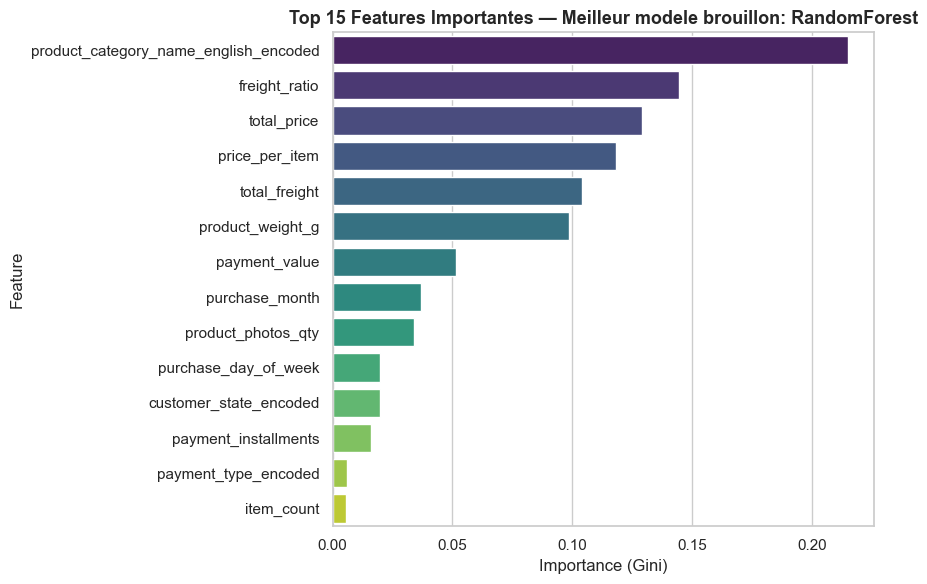

In [13]:
from src.evaluation import plot_feature_importance

# Important: on utilise le meilleur modele du brouillon, pas best_rf du notebook final
plot_feature_importance(
    best_overall_model,
    feature_names,
    model_name=f'Meilleur modele brouillon: {best_overall_algo}',
    top_n=15
)

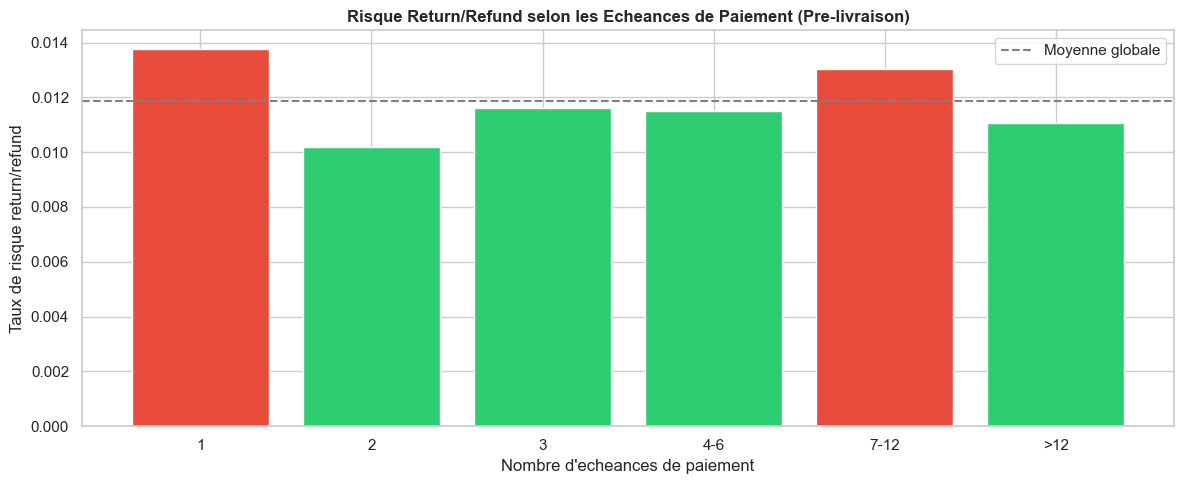


Insight: plus le paiement est etale, plus le risque peut augmenter selon les segments.


In [14]:
# Analyse pre-livraison : risque return/refund selon le nombre d'echeances de paiement
df_analysis = df_temp[df_temp['payment_installments'].notna()].copy()

bins = [0, 1, 2, 3, 6, 12, 24]
labels = ['1', '2', '3', '4-6', '7-12', '>12']
df_analysis['installments_bucket'] = pd.cut(df_analysis['payment_installments'], bins=bins, labels=labels, include_lowest=True)

risk_by_installments = df_analysis.groupby('installments_bucket')['is_return_refund_risk'].mean()

plt.figure(figsize=(12, 5))
plt.bar(
    risk_by_installments.index.astype(str),
    risk_by_installments.values,
    color=['#e74c3c' if v > risk_by_installments.mean() else '#2ecc71' for v in risk_by_installments.values]
 )
plt.axhline(y=risk_by_installments.mean(), color='gray', linestyle='--', label='Moyenne globale')
plt.xlabel('Nombre d\'echeances de paiement')
plt.ylabel('Taux de risque return/refund')
plt.title('Risque Return/Refund selon les Echeances de Paiement (Pre-livraison)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('\nInsight: plus le paiement est etale, plus le risque peut augmenter selon les segments.')

---
## 10. Analyse des Erreurs (Return/Refund)

On analyse les erreurs du meilleur modèle du brouillon.
- Faux Positifs: commandes low risk predites high risk (sur-allocation d'actions)
- Faux Negatifs: commandes high risk predites low risk (risque business)

Dans ce cas d'usage, les faux negatifs sont souvent les plus couteux.

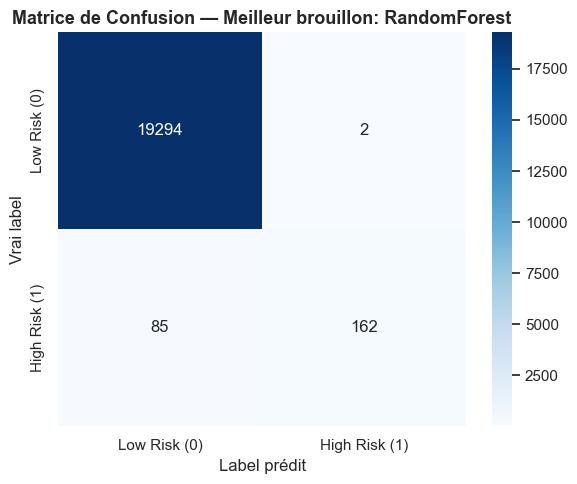

In [15]:
from src.evaluation import plot_confusion_matrix

plot_confusion_matrix(
    best_overall_model,
    X_test,
    y_test,
    model_name=f'Meilleur brouillon: {best_overall_algo}'
)

In [16]:
# Bilan erreurs du meilleur modele du brouillon
y_pred_exp = best_overall_model.predict(X_test)

errors_mask = y_pred_exp != y_test.values
print(f"Nombre total d'erreurs : {errors_mask.sum():,} ({errors_mask.sum()/len(y_test)*100:.1f}%)")

fp = ((y_pred_exp == 1) & (y_test.values == 0)).sum()
fn = ((y_pred_exp == 0) & (y_test.values == 1)).sum()
print(f'  Faux Positifs (FP) : {fp:,}')
print(f'  Faux Negatifs (FN) : {fn:,}')

Nombre total d'erreurs : 87 (0.4%)
  Faux Positifs (FP) : 2
  Faux Negatifs (FN) : 85


---
## 11. Conclusion des Essais

Ce notebook conserve uniquement les essais d'algorithmes pour
Return/Refund Propensity Classification.

In [17]:
# Tableau final des essais (top 20)
display(
    df_trials.sort_values(['f1', 'auc', 'accuracy'], ascending=False).head(20)
)

print('\nModele recommande pour 02_Modeling.ipynb:')
print(f"- {best_overall_algo} (selon F1 weighted maximal)")

,algorithm,trial_id,accuracy,f1,auc,params
7,RandomForest,2,0.995548,0.995104,0.884274,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
8,RandomForest,3,0.995497,0.995054,0.893882,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
6,RandomForest,1,0.995446,0.995004,0.884340,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
11,XGBoost,3,0.994371,0.994016,0.882276,"{'objective': 'binary:logistic', 'base_score':..."
9,XGBoost,1,0.987566,0.988429,0.891853,"{'objective': 'binary:logistic', 'base_score':..."
10,XGBoost,2,0.986031,0.987311,0.884779,"{'objective': 'binary:logistic', 'base_score':..."
3,DecisionTree,1,0.924781,0.950889,0.863957,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
4,DecisionTree,2,0.900220,0.936977,0.834820,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
5,DecisionTree,3,0.899094,0.936330,0.827791,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
0,LogReg,1,0.681113,0.798565,0.794982,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."



Modele recommande pour 02_Modeling.ipynb:
- RandomForest (selon F1 weighted maximal)


### Decision de transfert vers le notebook final

Reporter dans `02_Modeling.ipynb` uniquement:
1. La meilleure configuration par algorithme si necessaire.
2. Le meilleur modèle global pour la section modèle final.

Le brouillon reste dédié aux essais et comparaisons de paramètres.